# Connection：从事件源到已放置突触

本教程与 [synapse.ipynb](../synapse/synapse.ipynb) 配对。前者负责创建 postsynaptic dynamical entities；这里从已有的 `SynapseView` 出发，只讨论事件如何通过 Connection 到达突触。

底层关系始终是：`EventSource -> Connection -> Synapse`。本教程使用底层通用入口 `braincell.connect()`，不涉及 Network 的 place-and-connect 快捷接口。

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import braincell
from braincell import mech
from braincell.filter import AllRegion, at

brainstate.environ.set(precision=64)

## 1. 三类对象和一行 Connection

| 层 | 用户对象 | 保存内容 | 职责 |
|---|---|---|---|
| source | `EventSource` / `EventSourceView` | schedule 或 live detector | 产生离散事件 |
| routing | `ConnectionView` | source ID、synapse ID、`weight`、`delay` | 把事件路由到目标 |
| target | `SynapseView` / runtime SoA | `tau`、`e`、`g` 等参数和状态 | 消费事件并推进动力学 |

第 $c$ 行 routing record 可以写成

$$r_c=(s_c, j_c, w_c, d_c),$$

其中 $s_c$ 是 source endpoint，$j_c$ 是 logical synapse，$w_c$ 和 $d_c$ 分别是事件 payload 与 delay。多个 rows 可以指向同一个 $j_c$；到达同一突触、同一时间边界的 scalar payload 会在该突触上求和。

`connect(...)` 接受具体 source owner/view 和已经放置好的 `SynapseView`，不接受尚未实例化的位置声明。所有 view 都是保序、保重复的轻量索引，不复制底层列。

## 2. 一个最小但可运行的 postsynaptic Cell

下面建立与 [synapse.ipynb](../synapse/synapse.ipynb) 相同风格的三分支 3D morphology。四个 population members 共享 morphology 和 CV layout；`CableProperty + IL` 构成真实的 passive membrane，`staggered` solver 将在最后一节正常推进它。

In [2]:
soma = braincell.Branch.from_points(
    points=np.asarray([[-10.0, 0.0, 0.0], [10.0, 0.0, 0.0]]) * u.um,
    radii=np.asarray([10.0, 10.0]) * u.um, type="soma",
)
dend_a = braincell.Branch.from_points(
    points=np.asarray([[0.0, 0.0, 0.0], [0.0, 120.0, 0.0]]) * u.um,
    radii=np.asarray([2.0, 1.0]) * u.um, type="basal_dendrite",
)
dend_b = braincell.Branch.from_points(
    points=np.asarray([[0.0, 0.0, 0.0], [-120.0, -120.0, 60.0]]) * u.um,
    radii=np.asarray([2.5, 0.8]) * u.um, type="apical_dendrite",
)

morphology = braincell.Morphology.from_root(soma, name="soma")
morphology.soma.attach(dend_a, name="dend_a", parent_x=0.5)
morphology.soma.attach(dend_b, name="dend_b", parent_x=0.5)

post = braincell.Cell(
    morphology,
    cv_policy=braincell.CVPerBranchList((1, 2, 3)),
    pop_size=(4,), V_init=-65.0 * u.mV,
    solver="staggered", name="post",
)
post.paint(
    AllRegion(),
    mech.CableProperty(
        resting_potential=-65.0 * u.mV,
        membrane_capacitance=1.0 * u.uF / u.cm**2,
        axial_resistivity=100.0 * u.ohm * u.cm,
    ),
    mech.Channel(
        "IL", name="leak",
        g_max=0.3 * u.mS / u.cm**2, E=-54.387 * u.mV,
    ),
)

assert post.n_cv == 6
post

Cell(root='soma', n_branches=3, n_paint_rules=2, n_place_rules=0, initialized=False)

## 3. 先放置 Synapse，再对齐 endpoints

这里放置四个命名组。`ExpSyn` 和 `Exp2Syn` 都消费 conductance payload，但具有不同动力学；一次 `connect()` 必须选择一个确定的 synapse type 和 name。不同连接调用可以自由指向不同类型。

In [3]:
zip_syn = mech.Synapse(
    "ExpSyn", name="zip_syn", tau=2.0 * u.ms, e=0.0 * u.mV,
)
fanout_syn = mech.Synapse(
    "ExpSyn", name="fanout_syn", tau=3.0 * u.ms, e=0.0 * u.mV,
)
fanin_syn = mech.Synapse(
    "Exp2Syn", name="fanin_syn",
    tau1=0.5 * u.ms, tau2=4.0 * u.ms, e=-75.0 * u.mV,
)
explicit_syn = mech.Synapse(
    "Exp2Syn", name="explicit_syn",
    tau1=0.8 * u.ms, tau2=6.0 * u.ms, e=0.0 * u.mV,
)

post.place(at("dend_a", 0.25), zip_syn)
post.place(at("dend_a", 0.75), fanout_syn)
post[0].place(at("dend_b", 0.50), fanin_syn)
post.place(at("dend_b", 0.75), explicit_syn)

pd.crosstab(
    [post.synapses.synapse_type, post.synapses.name],
    post.synapses.population_index,
    rownames=["type", "name"], colnames=["cell"],
)

cell                  0  1  2  3
type    name                    
Exp2Syn explicit_syn  1  1  1  1
        fanin_syn     1  0  0  0
ExpSyn  fanout_syn    1  1  1  1
        zip_syn       1  1  1  1

### Endpoint 对齐和 row 参数广播

不传 `pairing=` 时，source 与 synapse views 使用下表规则。设 source 数为 $S$、synapse 数为 $T$、最终 rows 数为 $C$：

| endpoint shapes | 结果 | $C$ |
|---|---|---:|
| $S=T$ | 按当前 view 顺序逐行 zip | $S$ |
| $S=1$ | 同一 source fan-out 到全部 synapses | $T$ |
| $T=1$ | 全部 sources fan-in 到同一 synapse | $S$ |
| 其他 | 两侧先用保重复索引显式展开到等长，否则报错 | 显式长度 |

`weight` 和 `delay` 在对齐后只接受 scalar 或 shape `(C,)`。weight 的量纲由目标 synapse model 的 `event_input` 检查；`ExpSyn/Exp2Syn` 要求 conductance。默认 weight 为 `1 uS`，负值在声明层允许。delay 必须是非负时间量。

In [4]:
stim4 = braincell.NetStim(
    size=4, start=50.0 * u.ms, number=1, name="stim4",
)
stim1 = braincell.NetStim(
    size=1, start=50.0 * u.ms, number=1, name="stim1",
)

zipped = braincell.connect(
    "zip_input", source=stim4, synapse=post.synapses["zip_syn"],
    weight=np.asarray([0.10, 0.20, 0.30, 0.40]) * u.uS,
)
fanout = braincell.connect(
    "fanout_input", source=stim1, synapse=post.synapses["fanout_syn"],
    weight=0.15 * u.uS,
)
fanin = braincell.connect(
    "fanin_input", source=stim4, synapse=post.synapses["fanin_syn"],
    delay=np.arange(4) * u.ms,
)

# 两边相同长度的重复 views 表达任意显式关系。
explicit = braincell.connect(
    "explicit_input",
    source=stim4[[2, 0, 2, 1]],
    synapse=post.synapses["explicit_syn"][[1, 2, 1, 0]],
    weight=np.asarray([0.10, 0.20, -0.05, 0.30]) * u.uS,
    delay=np.asarray([0.0, 0.5, 1.0, 1.5]) * u.ms,
)

alignment_summary = pd.DataFrame({
    "case": ["zip", "fan-out", "fan-in", "explicit"],
    "rows": [len(v) for v in (zipped, fanout, fanin, explicit)],
    "source_ids": [v.source_index.tolist() for v in (zipped, fanout, fanin, explicit)],
    "target_cells": [v.synapse.population_index.tolist() for v in (zipped, fanout, fanin, explicit)],
})

np.testing.assert_array_equal(zipped.source_index, [0, 1, 2, 3])
np.testing.assert_array_equal(fanout.source_index, [0, 0, 0, 0])
np.testing.assert_array_equal(fanin.synapse.population_index, [0, 0, 0, 0])
np.testing.assert_array_equal(explicit.synapse.population_index, [1, 2, 1, 0])
alignment_summary

,case,rows,source_ids,target_cells
0,zip,4,"[0, 1, 2, 3]","[0, 1, 2, 3]"
1,fan-out,4,"[0, 0, 0, 0]","[0, 1, 2, 3]"
2,fan-in,4,"[0, 1, 2, 3]","[0, 0, 0, 0]"
3,explicit,4,"[2, 0, 2, 1]","[1, 2, 1, 0]"


## 4. ConnectionView：按语义筛选，再按 row 操作

`post.connections` 是该 Cell 拥有的全部 active routing rows。`len(view)` 始终返回 rows 数，而 `connect_names` 返回命中的命名调用。

| 查询 | 含义 |
|---|---|
| `connections["zip_input"]` | 按 connect name |
| `.by_source(stim4)` | 按 source owner identity |
| `.by_source_type("NetStim")` | 按 source model type |
| `.by_source_name("stim4")` | 按 source instance name |
| `.by_synapse_type("ExpSyn")` | 按 target dynamics type |
| `.by_synapse_name("explicit_syn")` | 按 target semantic name |
| `.for_population([0, 2])` | 按 postsynaptic cell IDs |
| `[0]`、`[1:4]`、整数/布尔数组 | 按当前 view 的 row 顺序 |

混合 synapse types 的 view 可以查看公共 routing 列，但不能直接读取 `weight`；不同 models 可能消费不同 payload，需先按 synapse type 收窄。

In [5]:
display(post.connections)

query_summary = pd.DataFrame({
    "query": [
        "post.connections",
        "connections['zip_input']",
        "by_source(stim4)",
        "by_source_type('NetStim')",
        "by_source_name('stim4')",
        "by_synapse_type('ExpSyn')",
        "by_synapse_name('explicit_syn')",
        "for_population([0, 2])",
    ],
    "rows": [
        len(post.connections),
        len(post.connections["zip_input"]),
        len(post.connections.by_source(stim4)),
        len(post.connections.by_source_type("NetStim")),
        len(post.connections.by_source_name("stim4")),
        len(post.connections.by_synapse_type("ExpSyn")),
        len(post.connections.by_synapse_name("explicit_syn")),
        len(post.connections.for_population([0, 2])),
    ],
})
query_summary

ConnectionView(cell=Cell(name='post'), rows=16, connects=4)
  zip_input: NetStim(stim4) -> ExpSyn(zip_syn), rows=4
  fanout_input: NetStim(stim1) -> ExpSyn(fanout_syn), rows=4
  fanin_input: NetStim(stim4) -> Exp2Syn(fanin_syn), rows=4
  explicit_input: NetStim(stim4) -> Exp2Syn(explicit_syn), rows=4

,query,rows
0,post.connections,16
1,connections['zip_input'],4
2,by_source(stim4),12
3,by_source_type('NetStim'),16
4,by_source_name('stim4'),12
5,by_synapse_type('ExpSyn'),8
6,by_synapse_name('explicit_syn'),4
7,"for_population([0, 2])",10


In [6]:
def connection_frame(view):
    return pd.DataFrame({
        "id": view.id,
        "source": view.source_index,
        "synapse": view.synapse_id,
        "target_cell": view.synapse.population_index,
        "weight_uS": view.weight.to_decimal(u.uS),
        "delay_ms": view.delay.to_decimal(u.ms),
    })


connection_frame(explicit)

,id,source,synapse,target_cell,weight_uS,delay_ms
0,12,2,13,1,0.10,0.0
1,13,0,14,2,0.20,0.5
2,14,2,13,1,-0.05,1.0
3,15,1,12,0,0.30,1.5


### 初始化前修改和删除

`.set()` 只修改当前 rows 的 `weight/delay`。`.remove()` 将 rows 标记为 inactive，但稳定 ID 留下空洞且不会复用。Cell 初始化后 topology 固定，这些声明操作都会被拒绝。

In [7]:
selected = explicit[[2, 0]]
selected.set(
    weight=np.asarray([0.25, -0.10]) * u.uS,
    delay=np.asarray([2.0, 0.25]) * u.ms,
)

removed_id = int(explicit[1].id[0])
explicit[1].remove()
later = braincell.connect(
    "later_input", source=stim1,
    synapse=post.synapses["explicit_syn"][3],
    weight=0.05 * u.uS,
)

assert removed_id not in explicit.id
assert int(later.id[0]) > removed_id
connection_frame(explicit)

,id,source,synapse,target_cell,weight_uS,delay_ms
0,12,2,13,1,-0.10,0.25
1,14,2,13,1,0.25,2.00
2,15,1,12,0,0.30,1.50


## 5. `pairing=`：从候选 endpoints 采样 Connection rows

显式索引适合已经知道每一行的情况；`pairing=` 则从两个不含重复 ID 的候选 views 生成 rows。这里采样的是**已经放置好的离散 endpoints**，所以参数名是 score，而不是连续 morphology 采样中的 density。结果仍写入同一 Connection store。

| helper | 哪个量决定 rows 数 | 语义 |
|---|---|---|
| `independent(number)` | 固定 $C=number$ | 两端独立采样 |
| `source_first(number)` | 固定 $C=number$ | 先采 source，再条件采 synapse |
| `synapse_first(number)` | 固定 $C=number$ | 先采 synapse，再条件采 source |
| `by_source(degree)` | $C=\sum_s d_s$ | 每个 source 指定下游数 |
| `by_synapse(degree)` | $C=\sum_j d_j$ | 每个 synapse 指定上游数 |
| `match_degrees(source_degree, synapse_degree)` | 两侧 stub sums 必须相等 | 展开并随机匹配两侧 stubs |

对一侧候选的 marginal score $q_j$，实际离散概率是

$$P(J=j)=\frac{q_j}{\sum_k q_k}.$$

先固定 source 再选择 synapse 时，score 可以同时依赖两端，形成条件概率

$$P(J=j\mid S=s)=\frac{q_{sj}}{\sum_k q_{sk}}.$$

score 必须返回有限、非负、无量纲的值，而且每个归一化行至少有一个正值。`degree` 可为整数、整数组或 `(ctx, rng) -> counts` callable；内置 `poisson`、`binomial`、`negative_binomial` 和 `empirical`。`replace=False` 的唯一性只在当前固定 endpoint 的候选 partners 内成立。

| 信息 | 典型表达 | 可构造的偏好 |
|---|---|---|
| source ID / population | `ctx.source.id`、`.population_index` | 显式先验、同群连接 |
| source 属性 | `ctx.source.get("start")` | 较早或较活跃的输入 |
| synapse 位置 | `branch_id/branch_x/cv_id` | branch mask、局部位置偏好 |
| morphology 几何 | `radius`、`path_distance_from_soma` | 粗树突或远端偏好 |
| 三维坐标 | `ctx.synapse.position` | 空间 Gaussian、source-target 距离核 |
| synapse 参数 | `ctx.synapse.get("tau")` | 按动力学参数加权 |
| target-cell 分组 | `ctx.group.*` | `group_by="target_cell"` 后的局部规则 |

marginal score 中候选端通常是 shape `(1, K)`；conditional score 中固定端是 `(B, 1)`、候选端是 `(1, K)`，两者可直接广播成 pairwise `(B, K)`。degree callable 只考察被计数的一侧，因此看到一维 shape `(K,)`。

In [8]:
sampled_syn = mech.Synapse(
    "ExpSyn", name="sampled_syn", tau=2.5 * u.ms, e=0.0 * u.mV,
)
post.place(post.cv_midpoints, sampled_syn)
sampled_targets = post.synapses[sampled_syn]  # 6 CV midpoints × 4 cells
pairing_source = braincell.NetStim(
    size=4, start=np.asarray([50.0, 60.0, 70.0, 80.0]) * u.ms,
    number=1, name="pairing_stim",
)

source_positions = np.asarray([
    [0.0, 30.0, 0.0], [0.0, 90.0, 0.0],
    [-25.0, -25.0, 12.5], [-90.0, -90.0, 45.0],
]) * u.um
branch_names = np.asarray(["soma", "dend_a", "dend_b"])

assert len(sampled_targets) == 24
pd.DataFrame({
    "branch": branch_names[sampled_targets.branch_id],
    "branch_x": sampled_targets.branch_x,
}).value_counts(sort=False).rename("candidate synapses").reset_index()

,branch,branch_x,candidate synapses
0,soma,0.500000,4
1,dend_a,0.250000,4
2,dend_a,0.750000,4
3,dend_b,0.166667,4
4,dend_b,0.500000,4
5,dend_b,0.833333,4


### 5.1 固定总行数：均匀基线与远端偏好

先用 `independent(300)` 建立均匀基线。第二次采样保持相同 seed，但让 synapse score 随到 soma 的树路径距离指数增长：

$$q_j=\exp\left(\frac{d_{\mathrm{soma},j}}{60\,\mu m}\right).$$

这里并没有重新在 morphology 上生成位置；24 个候选 synapses 已经固定，只是远端候选在离散抽样中获得了更大的概率。

In [9]:
def distal_synapse_score(ctx):
    distance = ctx.synapse.path_distance_from_soma
    return u.math.exp(distance / (60.0 * u.um))


uniform_pairs = braincell.connect(
    "uniform_pairs", source=pairing_source, synapse=sampled_targets,
    pairing=braincell.network.connection.independent(300, seed=21),
    weight=0.08 * u.uS,
)
distal_pairs = braincell.connect(
    "distal_pairs", source=pairing_source, synapse=sampled_targets,
    pairing=braincell.network.connection.independent(
        300, synapse_score=distal_synapse_score, seed=21,
    ),
    weight=0.08 * u.uS,
)

assert len(uniform_pairs) == len(distal_pairs) == 300
assert distal_pairs.synapse.branch_x.mean() > uniform_pairs.synapse.branch_x.mean()
pd.DataFrame({
    "pairing": ["uniform", "distal score"],
    "rows": [len(uniform_pairs), len(distal_pairs)],
    "mean selected branch_x": [
        uniform_pairs.synapse.branch_x.mean(),
        distal_pairs.synapse.branch_x.mean(),
    ],
})

,pairing,rows,mean selected branch_x
0,uniform,300,0.502778
1,distal score,300,0.664722


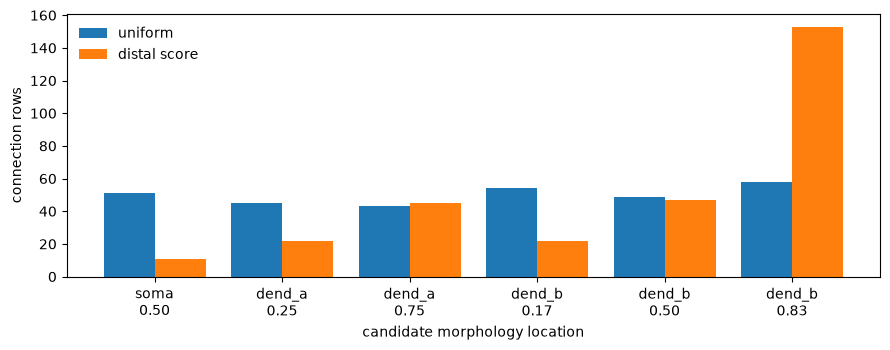

In [10]:
def target_hits(view):
    return np.bincount(view.target_index, minlength=len(sampled_targets))


location_hits = pd.DataFrame({
    "branch": branch_names[sampled_targets.branch_id],
    "branch_x": sampled_targets.branch_x,
    "uniform": target_hits(uniform_pairs),
    "distal score": target_hits(distal_pairs),
}).groupby(["branch", "branch_x"], sort=False, as_index=False).sum()

x = np.arange(len(location_hits))
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(x - 0.2, location_hits["uniform"], 0.4, label="uniform")
ax.bar(x + 0.2, location_hits["distal score"], 0.4, label="distal score")
ax.set(
    ylabel="connection rows", xlabel="candidate morphology location",
    xticks=x,
    xticklabels=[f"{b}\n{x:.2f}" for b, x in zip(location_hits.branch, location_hits.branch_x)],
)
ax.legend(frameon=False)
fig.tight_layout()

### 5.2 条件采样：source–synapse 三维距离核

`source_first` 先抽出 source，再为每个已抽出的 source 单独计算全部 synapse 候选的分数。`NetStim` 本身没有空间字段，因此这里显式给出 `source_positions`，再以 `ctx.source.id` 索引；synapse 坐标直接来自 morphology：

$$q_{sj}=\exp\left[-\frac{1}{2}\left\|\frac{x_s-x_j}{25\,\mu m}\right\|^2\right].$$

`ctx.source.id` 的 shape 是 `(B, 1)`，`ctx.synapse.position` 是 `(1, K, 3)`，相减后自然得到 `(B, K, 3)`，最后沿坐标轴求和得到 `(B, K)` score。

In [11]:
def spatial_synapse_score(ctx):
    delta = (source_positions[ctx.source.id] - ctx.synapse.position) / (25.0 * u.um)
    return u.math.exp(-0.5 * u.math.sum(delta**2, axis=-1))


spatial_pairs = braincell.connect(
    "spatial_pairs", source=pairing_source, synapse=sampled_targets,
    pairing=braincell.network.connection.source_first(
        300, synapse_score=spatial_synapse_score, seed=22,
    ),
    weight=0.08 * u.uS,
)


def nearby_branch_fraction(view):
    expected_branch = np.where(view.source_index < 2, 1, 2)
    return np.mean(view.synapse.branch_id == expected_branch)


uniform_nearby = nearby_branch_fraction(uniform_pairs)
spatial_nearby = nearby_branch_fraction(spatial_pairs)
assert spatial_nearby > 0.8
assert spatial_nearby > uniform_nearby
pd.DataFrame({
    "pairing": ["uniform", "3-D distance kernel"],
    "rows": [len(uniform_pairs), len(spatial_pairs)],
    "fraction on nearby dendrite": [uniform_nearby, spatial_nearby],
})

,pairing,rows,fraction on nearby dendrite
0,uniform,300,0.420000
1,3-D distance kernel,300,0.863333


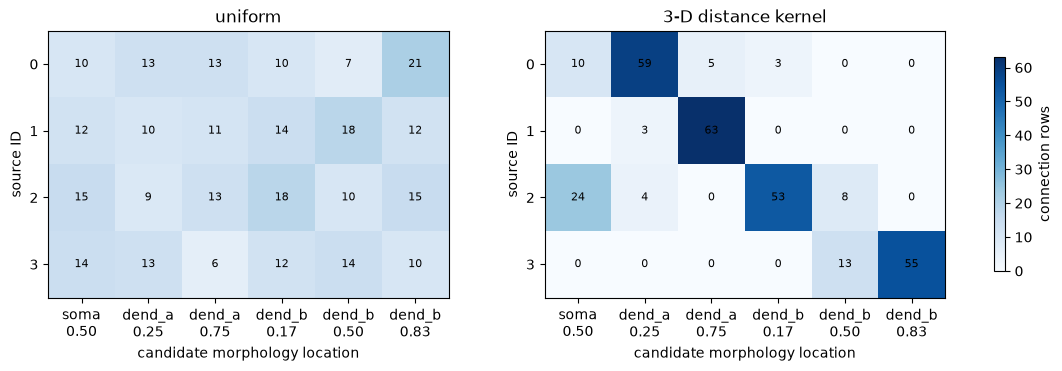

In [12]:
location_keys = list(dict.fromkeys(
    zip(sampled_targets.branch_id.tolist(), sampled_targets.branch_x.tolist())
))
location_lookup = {key: index for index, key in enumerate(location_keys)}
candidate_location_index = np.asarray([
    location_lookup[key]
    for key in zip(sampled_targets.branch_id.tolist(), sampled_targets.branch_x.tolist())
])
location_labels = [f"{branch_names[b]}\n{x:.2f}" for b, x in location_keys]


def location_count_matrix(view):
    matrix = np.zeros((4, len(location_keys)), dtype=int)
    np.add.at(matrix, (view.source_index, candidate_location_index[view.target_index]), 1)
    return matrix


matrices = [location_count_matrix(uniform_pairs), location_count_matrix(spatial_pairs)]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
for ax, matrix, title in zip(axes, matrices, ["uniform", "3-D distance kernel"]):
    image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=max(m.max() for m in matrices))
    for source_id, location_id in np.ndindex(matrix.shape):
        ax.text(location_id, source_id, matrix[source_id, location_id],
                ha="center", va="center", fontsize=8)
    ax.set(
        xlabel="candidate morphology location", ylabel="source ID", title=title,
        xticks=np.arange(len(location_keys)), xticklabels=location_labels,
        yticks=np.arange(4),
    )
fig.colorbar(image, ax=axes, label="connection rows", shrink=0.8)

### 5.3 形态依赖的异质入度

`by_synapse` 先为每个 synapse 生成入度，再为每一行选择 source。这里让远端 synapse 的期望入度更高：

$$d_j=1+\operatorname{Poisson}\left(0.25+\frac{d_{\mathrm{soma},j}}{120\,\mu m}\right).$$

随后用 source 的 `start` 参数构造偏好 $q_s=\exp[-(start_s-50\,ms)/(20\,ms)]$。随机入度可能超过四个 source，因此这里使用 `replace=True`；同一个 source–synapse pair 可以对应多行 routing records。

In [13]:
def morphology_degree(ctx, rng):
    distance_um = np.asarray(ctx.synapse.path_distance_from_soma.to_decimal(u.um))
    rate = 0.25 + distance_um / 120.0
    return 1 + np.asarray(rng.poisson(rate, size=rate.shape), dtype=np.int64)


def early_source_score(ctx):
    start = ctx.source.get("start")
    return u.math.exp(-(start - 50.0 * u.ms) / (20.0 * u.ms))


degree_pairs = braincell.connect(
    "heterogeneous_degree_pairs",
    source=pairing_source, synapse=sampled_targets,
    pairing=braincell.network.connection.by_synapse(
        morphology_degree, source_score=early_source_score,
        replace=True, seed=23,
    ),
    weight=0.06 * u.uS,
)

actual_degree = np.bincount(degree_pairs.target_index, minlength=len(sampled_targets))
source_rows = np.bincount(degree_pairs.source_index, minlength=4)
assert actual_degree.min() >= 1
assert actual_degree.sum() == len(degree_pairs)
assert source_rows[0] > source_rows[-1]

degree_table = pd.DataFrame({
    "target cell": sampled_targets.population_index,
    "branch": branch_names[sampled_targets.branch_id],
    "branch_x": sampled_targets.branch_x,
    "actual in-degree": actual_degree,
})
source_table = pd.DataFrame({
    "source ID": np.arange(4),
    "start (ms)": pairing_source.start.to_decimal(u.ms),
    "connection rows": source_rows,
})
display(source_table)
degree_table

,source ID,start (ms),connection rows
0,0,50.0,21
1,1,60.0,12
2,2,70.0,5
3,3,80.0,2


,target cell,branch,branch_x,actual in-degree
0,0,soma,0.500000,1
1,0,dend_a,0.250000,2
2,0,dend_a,0.750000,2
3,0,dend_b,0.166667,1
4,0,dend_b,0.500000,4
5,0,dend_b,0.833333,2
6,1,soma,0.500000,1
7,1,dend_a,0.250000,1
8,1,dend_a,0.750000,1
9,1,dend_b,0.166667,2


[Text(0.5, 0, 'source ID'),
 Text(0, 0.5, 'connection rows'),
 Text(0.5, 1.0, 'source preference from NetStim.start'),

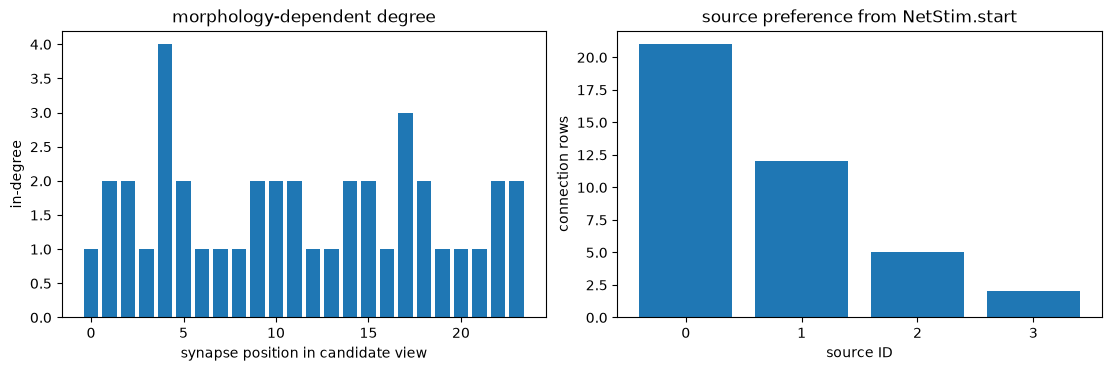

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
axes[0].bar(np.arange(len(actual_degree)), actual_degree)
axes[0].set(
    xlabel="synapse position in candidate view",
    ylabel="in-degree", title="morphology-dependent degree",
)
axes[1].bar(np.arange(4), source_rows)
axes[1].set(
    xlabel="source ID", ylabel="connection rows",
    title="source preference from NetStim.start", xticks=np.arange(4),
)

## 6. Scheduled source、weight 和 delay 的实际投递

| source | 时间来源 | 是否需要推进其他 Cell |
|---|---|---|
| `EventSequence` | 用户给出的 `EventTable` | 否 |
| `NetStim` | start/interval/number/noise 生成的 schedule | 否 |
| `cell.event_outputs["spike"]` | canonical root-CV threshold crossing | 是，由 Network 调度 source owner |
| `VoltageCrossingSource` | 指定位置、threshold 和方向 | 是，由 Network 调度 source owner |

本节只使用确定性的 scheduled source。事件时间与 delay 会量化到仿真边界：

$$t_{\mathrm{arrival}}=\operatorname{round\_half\_up}\!\left(\frac{t_{\mathrm{event}}+d_c}{dt}\right)dt.$$

这里所有时间恰好落在 `dt=0.025 ms` 的边界上，因此观察值应与 `event time + delay` 完全一致。

In [15]:
sequence = braincell.EventSequence(
    size=4,
    events=braincell.EventTable(
        source_index=[0, 1, 2, 3],
        time=np.asarray([1.0, 1.5, 2.0, 2.5]) * u.ms,
    ),
    name="explicit_schedule",
)
scheduled_syn = mech.Synapse(
    "ExpSyn", name="scheduled_syn", tau=3.0 * u.ms, e=0.0 * u.mV,
)
post.place(
    at("dend_a", 0.50),
    scheduled_syn,
    mech.MechanismProbe(
        name="g_scheduled", mechanism="scheduled_syn", field="g",
    ),
)
scheduled_connection = braincell.connect(
    "scheduled_input",
    source=sequence, synapse=post.synapses[scheduled_syn],
    weight=np.asarray([0.10, 0.20, 0.30, 0.40]) * u.uS,
    delay=np.asarray([0.0, 0.25, 0.50, 0.75]) * u.ms,
)

pd.DataFrame({
    "event_id": sequence.events.event_id,
    "source_id": sequence.events.source_index,
    "event_ms": sequence.events.time.to_decimal(u.ms),
    "weight_uS": scheduled_connection.weight.to_decimal(u.uS),
    "delay_ms": scheduled_connection.delay.to_decimal(u.ms),
})

,event_id,source_id,event_ms,weight_uS,delay_ms
0,0,0,1.0,0.1,0.00
1,1,1,1.5,0.2,0.25
2,2,2,2.0,0.3,0.50
3,3,3,2.5,0.4,0.75


In [16]:
result = post.run(dt=0.025 * u.ms, duration=4.0 * u.ms)
time_ms = result.time.to_decimal(u.ms)
g = np.asarray(result.traces["g_scheduled"].to_decimal(u.uS))

first_nonzero = np.asarray([
    np.flatnonzero(g[:, cell_id] > 0.0)[0] for cell_id in range(4)
])
observed_arrival_ms = time_ms[first_nonzero]
expected_arrival_ms = np.asarray([1.0, 1.75, 2.50, 3.25])
np.testing.assert_allclose(observed_arrival_ms, expected_arrival_ms, atol=1e-12)
assert np.all(np.diff(g.max(axis=0)) > 0.0)

arrival_table = pd.DataFrame({
    "source_id": np.arange(4),
    "event_ms": sequence.events.time.to_decimal(u.ms),
    "delay_ms": scheduled_connection.delay.to_decimal(u.ms),
    "expected_arrival_ms": expected_arrival_ms,
    "observed_arrival_ms": observed_arrival_ms,
    "peak_g_uS": g.max(axis=0),
})
arrival_table

,source_id,event_ms,delay_ms,expected_arrival_ms,observed_arrival_ms,peak_g_uS
0,0,1.0,0.00,1.00,1.00,0.099170
1,1,1.5,0.25,1.75,1.75,0.198340
2,2,2.0,0.50,2.50,2.50,0.297510
3,3,2.5,0.75,3.25,3.25,0.396681


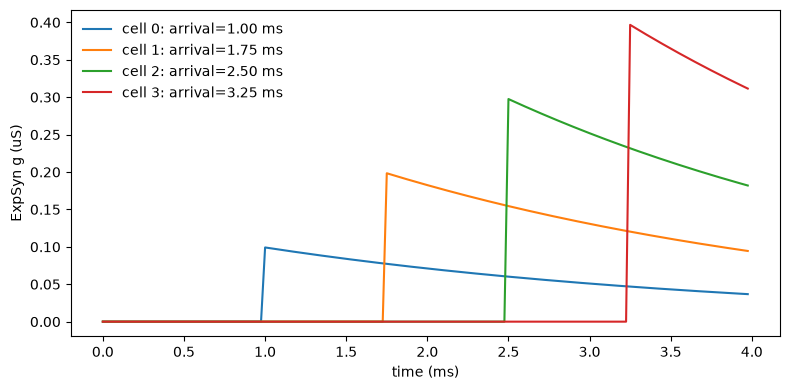

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
for cell_id in range(4):
    ax.plot(
        time_ms, g[:, cell_id],
        label=f"cell {cell_id}: arrival={observed_arrival_ms[cell_id]:.2f} ms",
    )
ax.set(xlabel="time (ms)", ylabel="ExpSyn g (uS)")
ax.legend(frameon=False)
fig.tight_layout()

## 总结

- `connect()` 将具体 EventSource endpoints 与已有 logical synapses 降为一行一个 routing record。
- 等长 zip、singleton 广播和显式重复 views 构成确定性 general mapping；`pairing=` 从唯一候选 views 采样相同 rows。
- score 将 `ctx` 中的 source、形态和 synapse 参数转成离散选择概率；degree 决定每个固定 endpoint 生成多少 rows。
- `ConnectionView` 按 connect/source/synapse/target-cell 语义筛选，再按 row 读取、修改或删除。
- `weight/delay` 属于 Connection，synapse dynamics parameters 和 states 属于 Synapse；多个 rows 可以共享同一 synapse。
- `EventSequence/NetStim` 可由目标 Cell 直接消费；来自其他 Cell 的 live sources 需要 Network 同时推进 source owner 和 target。
- 初始化后 topology 固定；继续运行只推进 state、时间与 delay queues。